# Analysis

## Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams['figure.dpi'] = 200

## Load data

In [2]:
train1_path = '../datasets/train_part_1.parquet'
train2_path = '../datasets/train_part_2.parquet'
train3_path = '../datasets/train_part_3.parquet'
labels_path = '../datasets/train_labels.parquet'

train1_df = pd.read_parquet(train1_path)
train2_df = pd.read_parquet(train2_path)
train3_df = pd.read_parquet(train3_path)
labels_df = pd.read_parquet(labels_path)

## Preprocess

#### Проверим размеры датасетов:

In [3]:
print(f"train1_df: {train1_df.shape}")
print(f"train1_df: {train2_df.shape}")
print(f"train1_df: {train3_df.shape}")
print(f"labels_df: {labels_df.shape}")

train1_df: (28618594, 23)
train1_df: (28558397, 23)
train1_df: (28500849, 23)
labels_df: (87514, 3)


#### Проверим колонки датасетов и их типы данных:

In [4]:
print("train1_df:")
for col in train1_df.columns:
    print(f"- {col}: {train1_df[col].dtype}")

print("\nlabels_df:")
for col in labels_df.columns:
    print(f"- {col}: {labels_df[col].dtype}")

train1_df:
- customer_id: int64
- event_id: int64
- event_dttm: str
- event_type_nm: int32
- event_desc: int32
- channel_indicator_type: int32
- channel_indicator_sub_type: int32
- operaton_amt: float64
- currency_iso_cd: float64
- mcc_code: str
- pos_cd: float64
- accept_language: str
- browser_language: str
- timezone: float64
- session_id: float64
- operating_system_type: float64
- battery: str
- device_system_version: str
- screen_size: str
- developer_tools: str
- phone_voip_call_state: float64
- web_rdp_connection: float64
- compromised: str

labels_df:
- customer_id: int64
- event_id: int64
- target: int32


#### Добавляем в датасеты признаков разметку по классам:

In [5]:
train1_df = pd.merge(train1_df, labels_df, on=['customer_id', 'event_id'], how='left')
train2_df = pd.merge(train2_df, labels_df, on=['customer_id', 'event_id'], how='left')
train3_df = pd.merge(train3_df, labels_df, on=['customer_id', 'event_id'], how='left')

In [6]:
print(train1_df['target'])

0          NaN
1          NaN
2          NaN
3          NaN
4          NaN
            ..
28618589   NaN
28618590   NaN
28618591   NaN
28618592   NaN
28618593   NaN
Name: target, Length: 28618594, dtype: float64


#### Заменяем пропущенные значения ("чистые" операции ранее имели NaN-значение):

In [7]:
train1_df['target'] = train1_df['target'].fillna(-1)
print(train1_df['target'])

0          -1.000
1          -1.000
2          -1.000
3          -1.000
4          -1.000
            ...  
28618589   -1.000
28618590   -1.000
28618591   -1.000
28618592   -1.000
28618593   -1.000
Name: target, Length: 28618594, dtype: float64


## Research 

#### Посмотрим, какое значение для анализа имеет каждый из признаков:

**Идентификационные данные**

`customer_id` - ID клиента  
`event_id` - ID операции  
`session_id` - ID сессии

Зачем: Позволяют выявлять аномальное поведение конкретного клиента или множественные операции в одной сессии

**Временные метки**

`event_dttm` - дата и время операции

Зачем: Фрод часто происходит в нерабочее время (ночью, в праздники)

**Типы операций**

`event_type_nm` - тип операции (например, покупка, перевод, снятие)  
`event_desc` - описание операции

Зачем: Некоторые типы операций более рискованны (например, крупные переводы)

**Каналы и устройства, с которых производится транзакция**

`channel_indicator_type` - тип канала (мобильное приложение, веб, терминал)  
`channel_indicator_sub_type` - подтип канала  
`operating_system_type` - ОС устройства  
`device_system_version` - версия ОС  
`screen_size` - размер экрана  
`battery` - уровень заряда батареи  
`phone_voip_call_state` - состояние VoIP звонка  
`browser_language` - язык браузера  
`accept_language` - Accept-Language заголовок  
`timezone` - часовой пояс  

Зачем:
* Несоответствие языка/часового пояса местоположению клиента
* Эмуляторы имеют специфические размеры экрана, уровень батареи (часто 100% или -1)
* VoIP состояние может указывать на подмену номера

**Финансовые данные**

`operaton_amt` - сумма операции  
`currency_iso_cd` - валюта

Зачем: Необычно крупные суммы, несоответствие валюты региону

**Геолокационные и торговые**

`mcc_code` - Merchant Category Code (код категории торговца)  
`pos_cd` - код точки продажи

Зачем: Подозрительные категории (казино, криптобиржи), несоответствие обычным паттернам покупок

**Технические признаки безопасности**

`developer_tools` - включены ли инструменты разработчика  
`web_rdp_connection` - подключение через RDP  
`compromised` - метка, что устройство/сессия скомпрометированы

Зачем:
* developer_tools = 1: попытка отладки/взлома
* web_rdp_connection = 1: удаленный доступ (частый признак мошенников)
* compromised = 1: уже известное скомпрометированное устройство

#### Проанализируем target:

Колонка `target` имеет значения 1, 0 и -1. Нам известно, что -1 - это самый часто встречающийся класс = "чистые" операции; два других означают подозрительные операции.

В задании указано, что **целевой класс, "красный свет" - это непотвержденные операции, класс 1.**  
Это означает, что когда банк зафиксировал подозрительную операцию, то связался с клиентом и задал вопрос "Это вы совершили операцию?" и клиент ответил "Нет, это не я".  
**Это и является фродом.**

Также имеется **"желтый свет"** - операции, подтвержденные клиентом - класс 0.  
Это означает, что когда банк зафиксировал подозрительную операцию, то клиент в ответ на вопрос банка подтвердил, что он сам совершил эту операцию.  
Это не целевой класс, не является фродом. Но он также может содержать выбросы по суммам или другие нетипичные значения в признаках.

Посмотрим "подозрительные" значения в обоих классах:

In [8]:
for val in [0, 1]:
    subset = train1_df[train1_df['target'] == val]
    print(f"Класс {val} (n = {len(subset)})")
    
    rdp_pct = subset['web_rdp_connection'].mean() * 100
    print(f"RDP: {rdp_pct:.2f}%")
    
    if 'developer_tools' in subset.columns:
        dev_tools_numeric = pd.to_numeric(subset['developer_tools'], errors='coerce')
        dev_pct = dev_tools_numeric.mean() * 100
        print(f"Developer tools: {dev_pct:.2f}%")

    if 'compromised' in subset.columns:
        comp_numeric = pd.to_numeric(subset['compromised'], errors='coerce')
        comp_pct = comp_numeric.mean() * 100
        print(f"Compromised: {comp_pct:.2f}%")
    
    print(f"Средняя сумма: {subset['operaton_amt'].mean():.0f}")
    print(f"Медианная сумма: {subset['operaton_amt'].median():.0f}")
    print(f"Максимальная сумма: {subset['operaton_amt'].max():.0f}\n")

Класс 0 (n = 12082)
RDP: 6.56%
Developer tools: 17.03%
Compromised: 0.17%
Средняя сумма: 22885937
Медианная сумма: 1010000
Максимальная сумма: 12762880000

Класс 1 (n = 17384)
RDP: 1.82%
Developer tools: 15.79%
Compromised: 0.03%
Средняя сумма: 7042597
Медианная сумма: 362916
Максимальная сумма: 1150380064



#### Значения для сабмита:

В примерах значений для сабмита есть числа типа -4, т.е. не вероятность (которая может быть только от 0 до 1).  

Это линейная комбинация весов признаков (буквально сумма значений признаков, умноженных на их веса, плюс сдвиг). Чем это значение меньше, тем ниже вероятность фрода, и наоборот.  
Это называется raw score (сырой скор), который легко конвертируется в вероятность и может быть получен в некоторых моделях напрямую вместо вероятности.

Например, в catboost:

`submission['predict'] = model.predict(X_test, prediction_type='RawFormulaVal')`

#### Распределение операций по времени суток:

Чистые, n = 28589128):
  День (8-18): 70.0%
  Вечер (19-23): 2.2%
  Ночь (0-4): 15.1%
  Утро (5-7): 12.7%

Подозр. подтв., n = 12082):
  День (8-18): 69.8%
  Вечер (19-23): 1.8%
  Ночь (0-4): 13.9%
  Утро (5-7): 14.4%

Фрод, n = 17384):
  День (8-18): 73.6%
  Вечер (19-23): 4.8%
  Ночь (0-4): 11.4%
  Утро (5-7): 10.2%



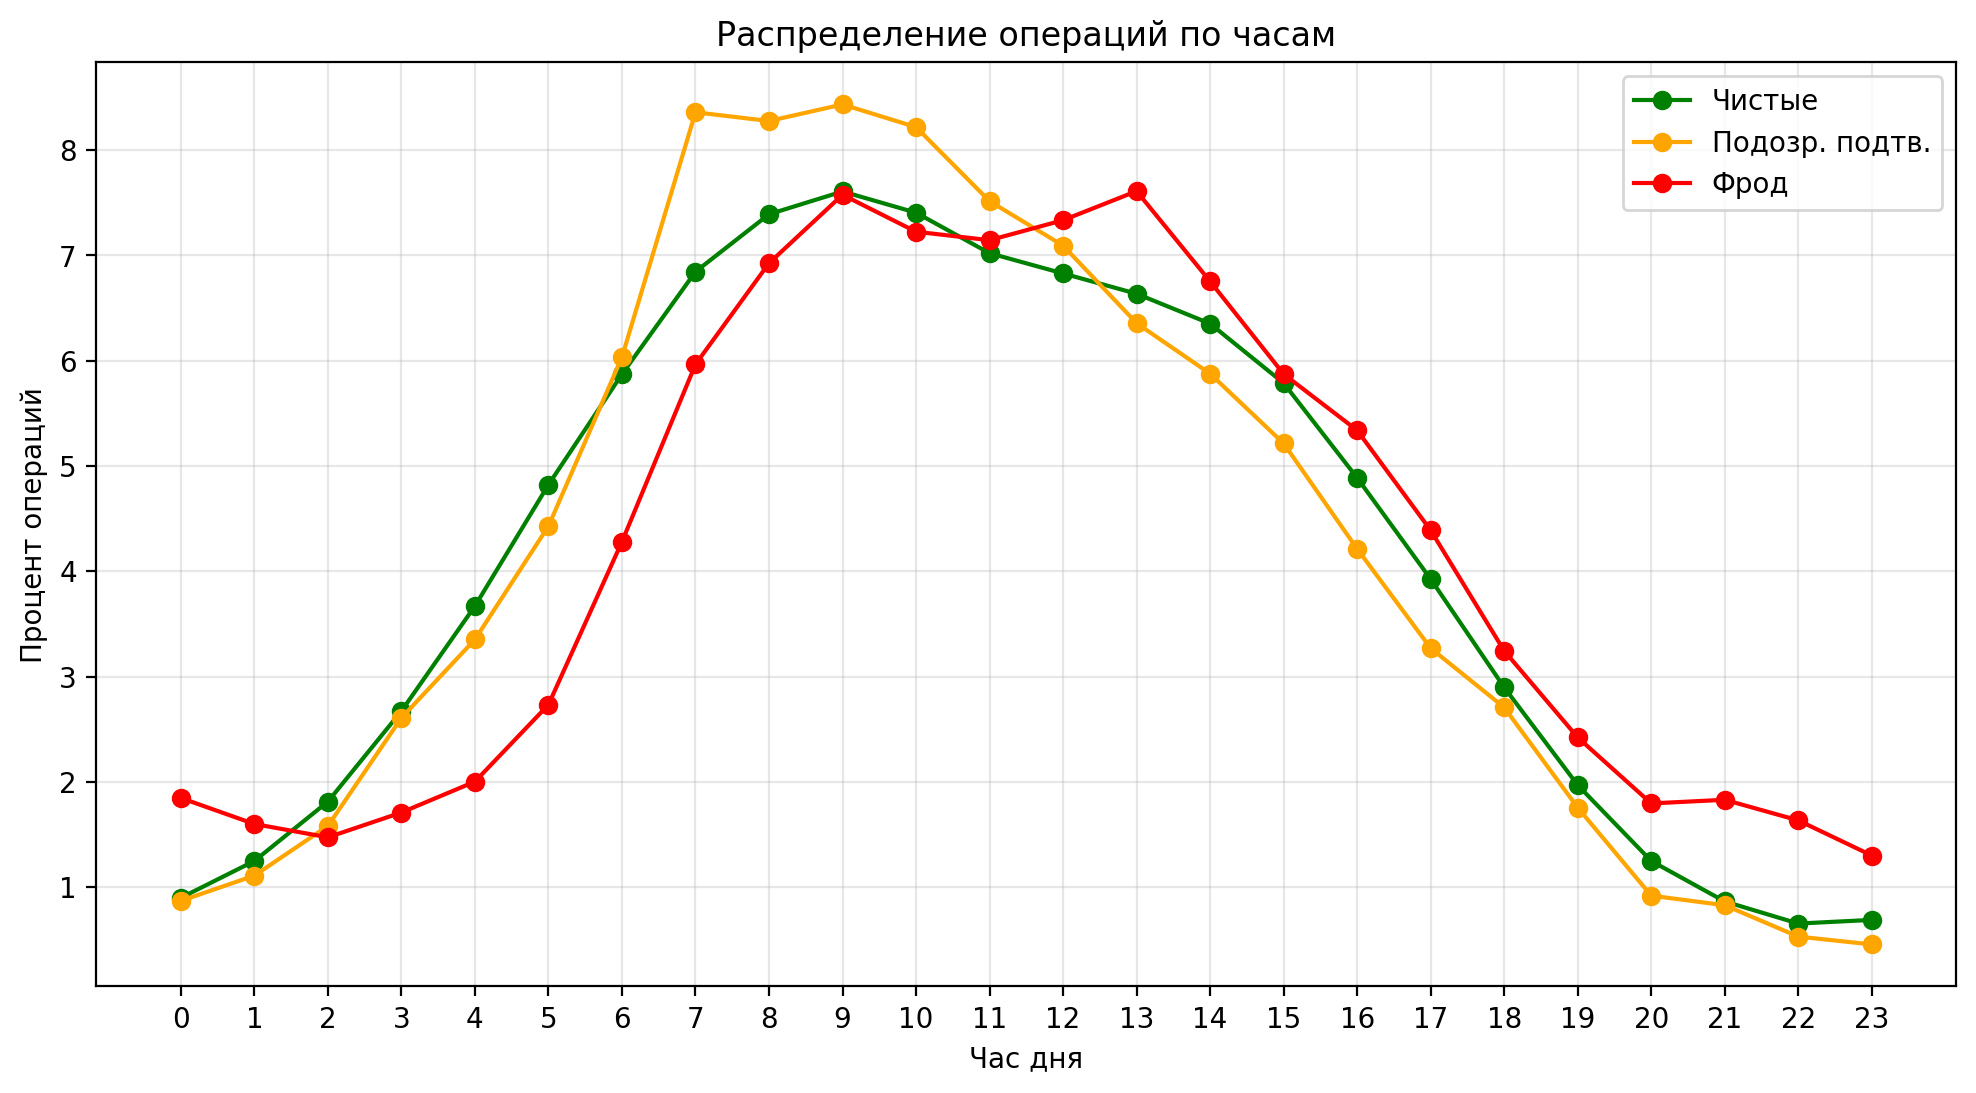

In [9]:
df_time = train1_df.copy()
df_time['event_dttm'] = pd.to_datetime(df_time['event_dttm'])
df_time['hour'] = df_time['event_dttm'].dt.hour
df_time['day_of_week'] = df_time['event_dttm'].dt.dayofweek
df_time['is_weekend'] = df_time['day_of_week'].isin([5, 6]).astype(int)
df_time['month'] = df_time['event_dttm'].dt.month
df_time['day_of_month'] = df_time['event_dttm'].dt.day

hourly_dist = {}
for val, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = df_time[df_time['target'] == val]
    hourly = subset['hour'].value_counts().sort_index()
    hourly_pct = (hourly / len(subset) * 100).round(2)
    hourly_dist[name] = hourly_pct
    
    print(f"{name}, n = {len(subset)}):")
    
    day_pct = (subset['hour'].between(8, 20)).mean() * 100
    night_pct = (subset['hour'].between(0, 5)).mean() * 100
    morning_pct = (subset['hour'].between(6, 7)).mean() * 100
    evening_pct = (subset['hour'].between(21, 23)).mean() * 100
    
    print(f"  День (8-18): {day_pct:.1f}%")
    print(f"  Вечер (19-23): {evening_pct:.1f}%")
    print(f"  Ночь (0-4): {night_pct:.1f}%")
    print(f"  Утро (5-7): {morning_pct:.1f}%\n")
    
fraud = df_time[df_time['target'] == 1]
fraud_hourly = fraud['hour'].value_counts().sort_index()
fraud_hourly_pct = fraud_hourly / len(fraud) * 100

plt.figure(figsize=(12, 6))

for val, name, color in [(-1, 'Чистые', 'green'), (0, 'Подозр. подтв.', 'orange'), (1, 'Фрод', 'red')]:
    subset = df_time[df_time['target'] == val]
    hourly = subset['hour'].value_counts().sort_index()
    hourly_pct = hourly / len(subset) * 100
    plt.plot(hourly_pct.index, hourly_pct.values, marker='o', label=name, color=color)

plt.xlabel('Час дня')
plt.ylabel('Процент операций')
plt.title('Распределение операций по часам')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(24))
plt.show()

Видим, что нет четкой зависимости вида операций от времени суток (фрод НЕ совершается чаще ночью и т.п.)

#### Распределение операций по дням недели:

Операции в выходные:
  Чистые: 24.2%
  Подозр. подтв.: 18.9%
  Фрод: 21.6%

Операции в праздники:
  Чистые: 3.6%
  Подозр. подтв.: 2.1%
  Фрод: 3.3%


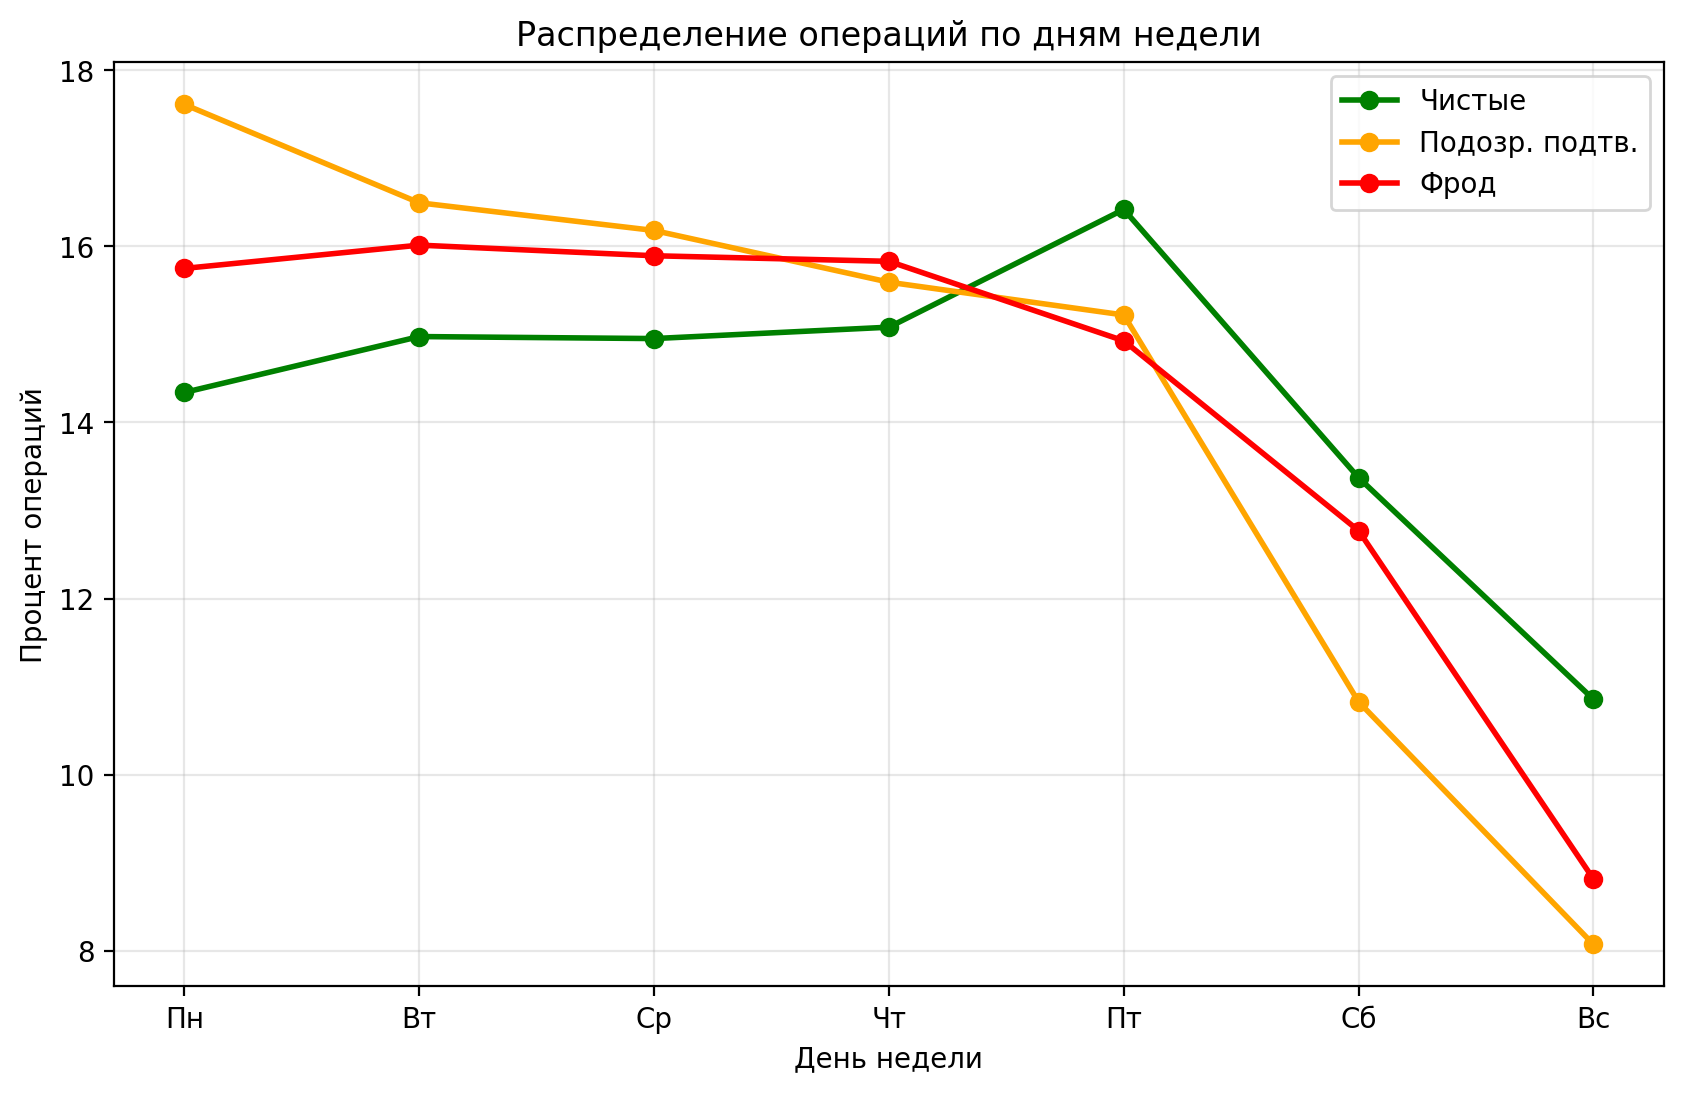

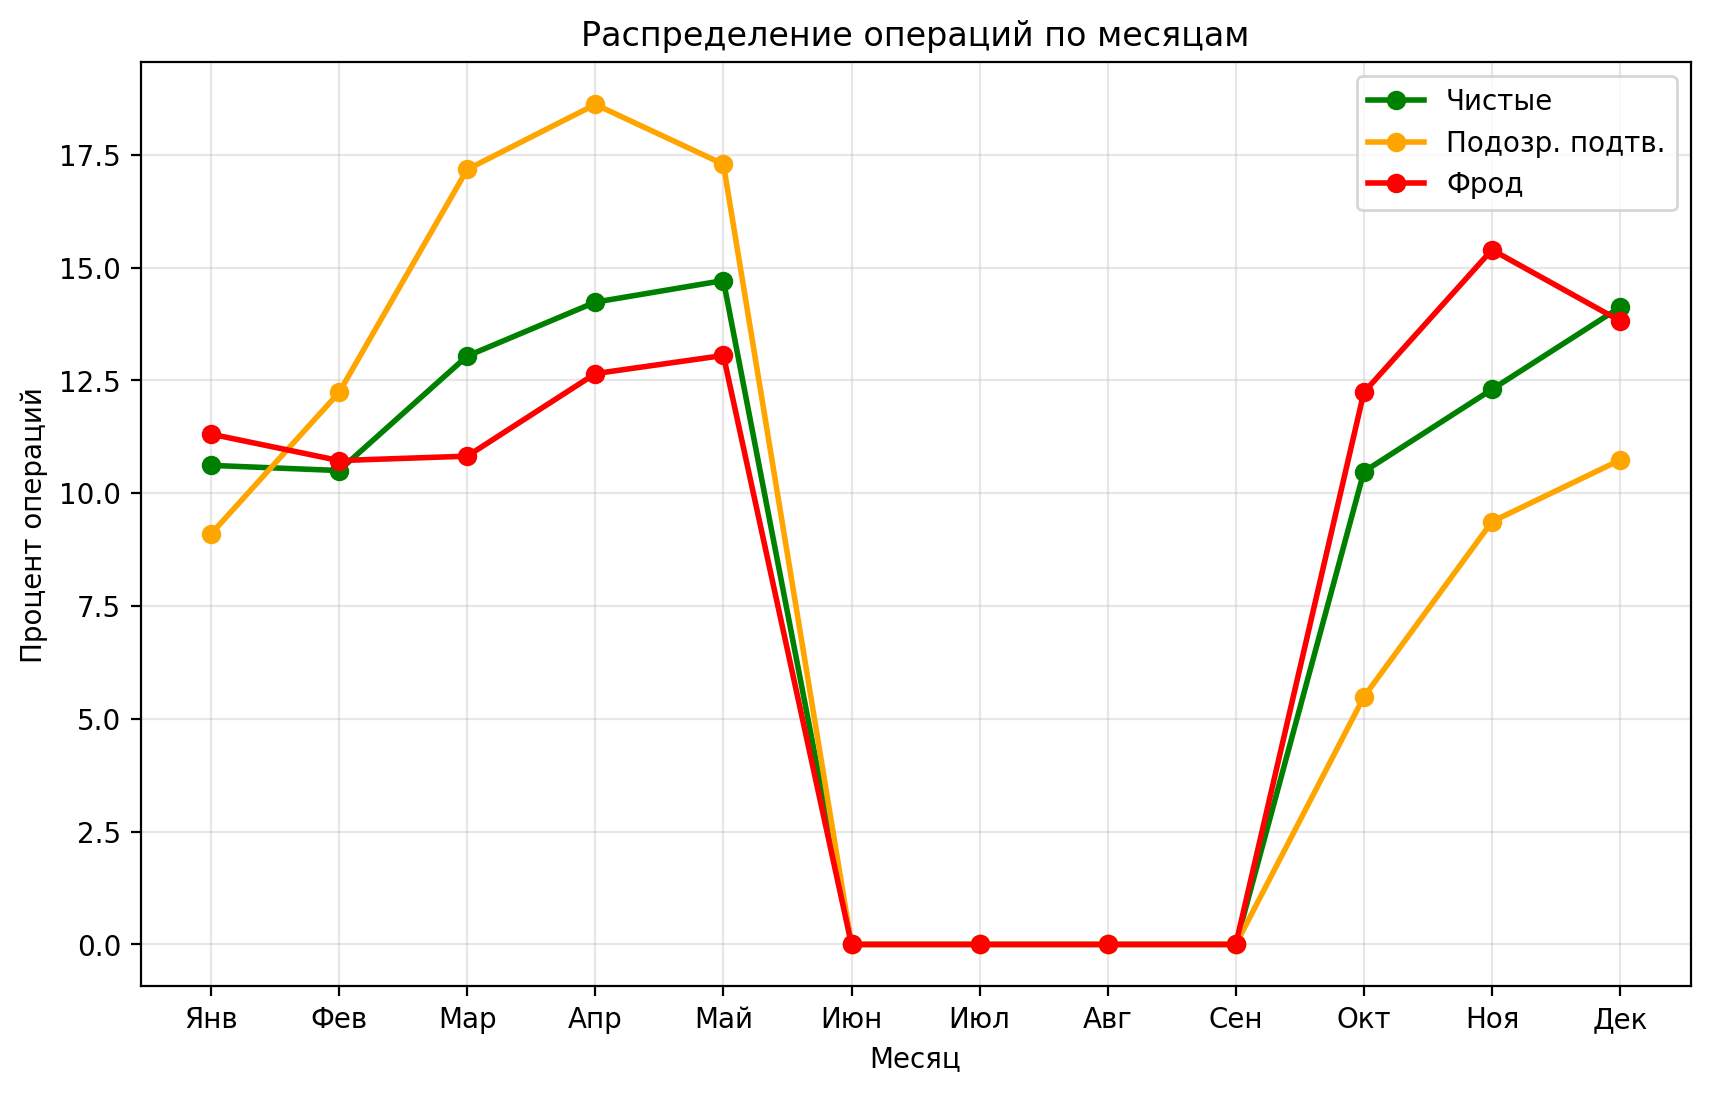

In [10]:
russian_holidays = [
    (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7),
    (2, 23),
    (3, 8),
    (5, 1), (5, 9),
    (6, 12),
    (11, 4),
]

df_time['is_holiday'] = df_time.apply(
    lambda row: (row['month'], row['day_of_month']) in russian_holidays, 
    axis=1
).astype(int)

print("Операции в выходные:")
for val, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = df_time[df_time['target'] == val]
    weekend_pct = subset['is_weekend'].mean() * 100
    print(f"  {name}: {weekend_pct:.1f}%")

print("\nОперации в праздники:")
for val, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = df_time[df_time['target'] == val]
    holiday_pct = subset['is_holiday'].mean() * 100
    print(f"  {name}: {holiday_pct:.1f}%")

plt.figure(figsize=(10, 6))

days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
for val, name, color in [(-1, 'Чистые', 'green'), (0, 'Подозр. подтв.', 'orange'), (1, 'Фрод', 'red')]:
    subset = df_time[df_time['target'] == val]
    dow_dist = subset['day_of_week'].value_counts().sort_index()
    dow_pct = (dow_dist / len(subset) * 100).reindex(range(7), fill_value=0)
    plt.plot(days, dow_pct.values, marker='o', label=name, color=color, linewidth=2)

plt.xlabel('День недели')
plt.ylabel('Процент операций')
plt.title('Распределение операций по дням недели')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))

months = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 
          'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
for val, name, color in [(-1, 'Чистые', 'green'), (0, 'Подозр. подтв.', 'orange'), (1, 'Фрод', 'red')]:
    subset = df_time[df_time['target'] == val]
    month_dist = subset['month'].value_counts().sort_index()
    month_pct = (month_dist / len(subset) * 100).reindex(range(1, 13), fill_value=0)
    plt.plot(months, month_pct.values, marker='o', label=name, color=color, linewidth=2)

plt.xlabel('Месяц')
plt.ylabel('Процент операций')
plt.title('Распределение операций по месяцам')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Распределение операций по часовым поясам:


Чистые (n=28589128):
  TZ 31: 1747434 оп. (63.6%)
  TZ 13: 338867 оп. (12.3%)
  TZ 21: 81005 оп. (2.9%)
  TZ 27: 76606 оп. (2.8%)
  TZ 16: 63038 оп. (2.3%)

Подозр./подтв. (n=12082):
  TZ 31: 1143 оп. (66.5%)
  TZ 13: 187 оп. (10.9%)
  TZ 27: 60 оп. (3.5%)
  TZ 21: 60 оп. (3.5%)
  TZ 16: 45 оп. (2.6%)

Фрод (n=17384):
  TZ 31: 716 оп. (60.6%)
  TZ 13: 108 оп. (9.1%)
  TZ 27: 61 оп. (5.2%)
  TZ 33: 50 оп. (4.2%)
  TZ 20: 34 оп. (2.9%)


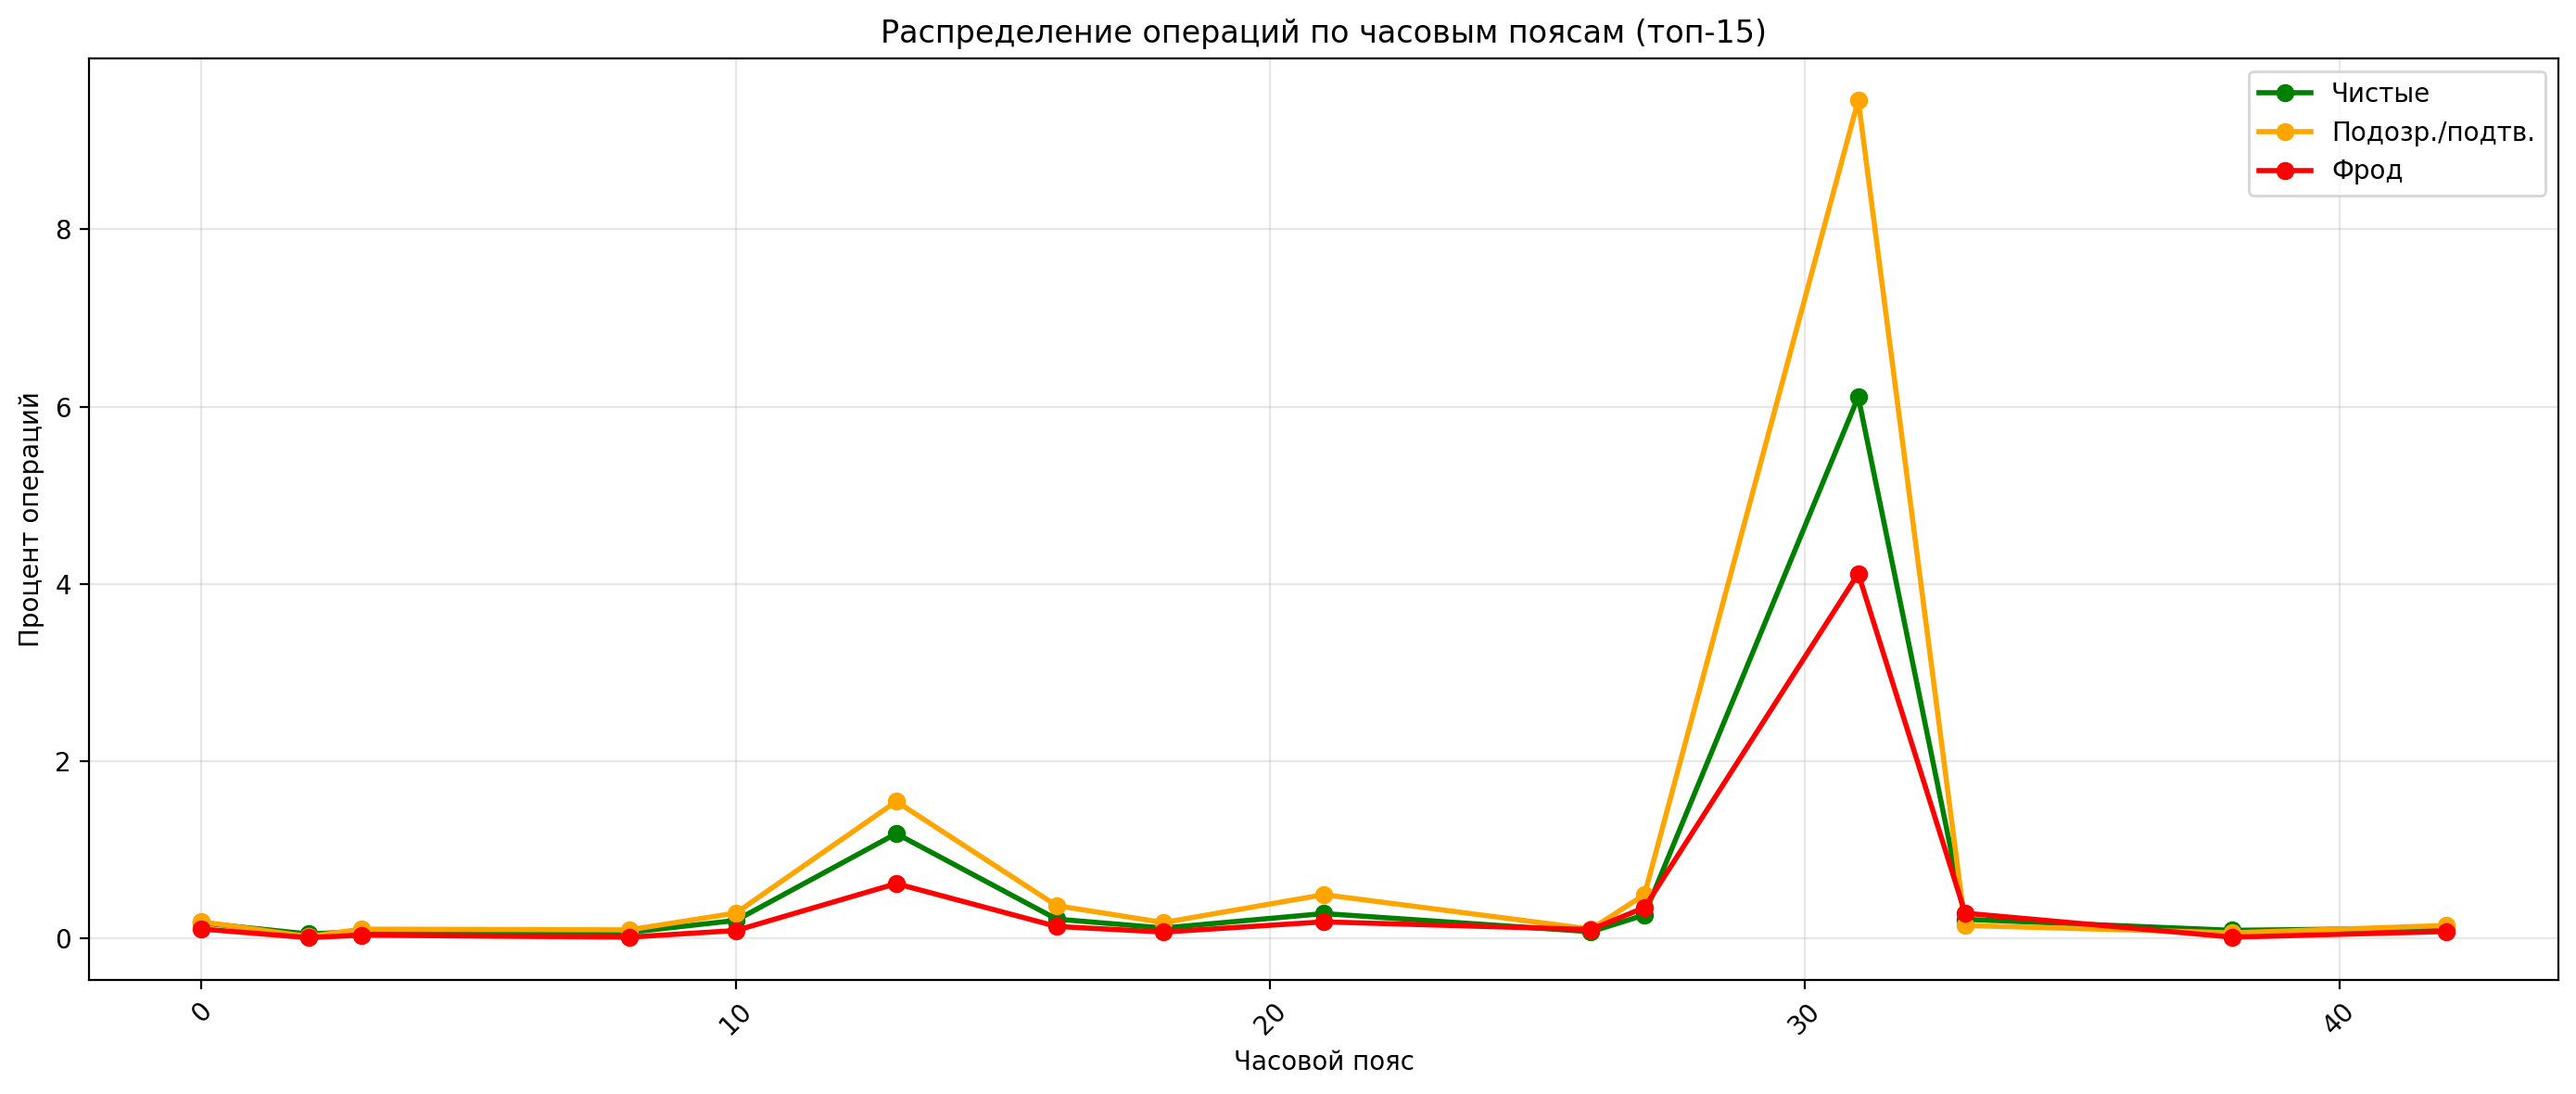

In [11]:
df_geo = train1_df.copy()

for val, name in [(-1, 'Чистые'), (0, 'Подозр./подтв.'), (1, 'Фрод')]:
    subset = df_geo[df_geo['target'] == val]
    print(f"\n{name} (n={len(subset)}):")
    
    # Топ-5 часовых поясов
    top_tz = subset['timezone'].value_counts().head(5)
    top_tz_pct = subset['timezone'].value_counts(normalize=True).head(5) * 100
    
    for tz, count in top_tz.items():
        pct = top_tz_pct[tz]
        print(f"  TZ {tz:.0f}: {count} оп. ({pct:.1f}%)")

plt.figure(figsize=(14, 6))

top15_tz = df_geo['timezone'].value_counts().head(15).sort_index()

for val, name, color in [(-1, 'Чистые', 'green'), (0, 'Подозр./подтв.', 'orange'), (1, 'Фрод', 'red')]:
    subset = df_geo[df_geo['target'] == val]

    tz_dist = subset['timezone'].value_counts()
    tz_dist_pct = (tz_dist / len(subset) * 100)
    tz_dist_pct = tz_dist_pct.reindex(top15_tz.index, fill_value=0)
    
    plt.plot(tz_dist_pct.index, tz_dist_pct.values, marker='o', label=name, color=color, linewidth=2)

plt.xlabel('Часовой пояс')
plt.ylabel('Процент операций')
plt.title('Распределение операций по часовым поясам (топ-15)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Анализ существующих признаков для предобработки:

#### battery

In [32]:
battery_vals = train1_df['battery'].unique()
print(f"Всего уникальных значений батареи: {len(battery_vals)}")

for i, val in enumerate(battery_vals):
    val_str = str(val)[:100]
    print(f"{val_str}")

Всего уникальных значений батареи: 118
nan
not available
93%
100%
76%
73%
69%
55.00000000000001%
54%
53%
61%
56.00000000000001%
42%
87%
51%
43%
98%
59%
6%
77%
99%
80%
89%
30%
96%
36%
62%
72%
47%
46%
79%
82%
78%
52%
22%
4%
85%
49%
71%
92%
94%
97%
18%
63%
81%
84%
64%
39%
66%
33%
90%
28.000000000000004%
60%
40%
32%
20%
34%
70%
38%
48%
74%
86%
41%
67%
14.000000000000002%
57.99999999999999%
25%
35%
50%
95%
44%
9%
17%
45%
65%
68%
91%
83%
75%
12%
27%
16%
28.999999999999996%
23%
19%
37%
21%
56.99999999999999%
88%
26%
24%
8%
11%
10%
0%
15%
31%
1%
2%
5%
3%
13%
NaN%
7.000000000000001%
:0%,User-Agent:Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chro
:100%,User-Agent:Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Ch
:100%,User-Agent:Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Ch
:100%,reducedMotion:false,mouseTimingV1:[],userAgent:Mozilla/5.0 (Windows NT 10.0; Win64; x64) Apple
:100%,User-Agen

Видим, что в колонке батареи есть как разные проценты, так и NaN-значения, и non available, и мусорные значения. Посмотрим их распределение.

  Проценты: 348427 (1.2174846885%)
  not available: 2301709 (8.0427046835%)
  NaN (пропуски): 25968432 (90.7397197780%)
  Мусор (длинные строки): 26 (0.0000908500%)

Чистые (n = 28589128):
  Проценты: 1.22%
  not available: 8.04%
  NaN (пропуски): 90.74%
  Мусор (длинные строки): 0.00%

Подозр/подтв (n = 12082):
  Проценты: 2.57%
  not available: 11.54%
  NaN (пропуски): 85.90%
  Мусор (длинные строки): 0.0000000000%

Фрод (n = 17384):
  Проценты: 2.23%
  not available: 4.35%
  NaN (пропуски): 93.42%
  Мусор (длинные строки): 0.0000000000%


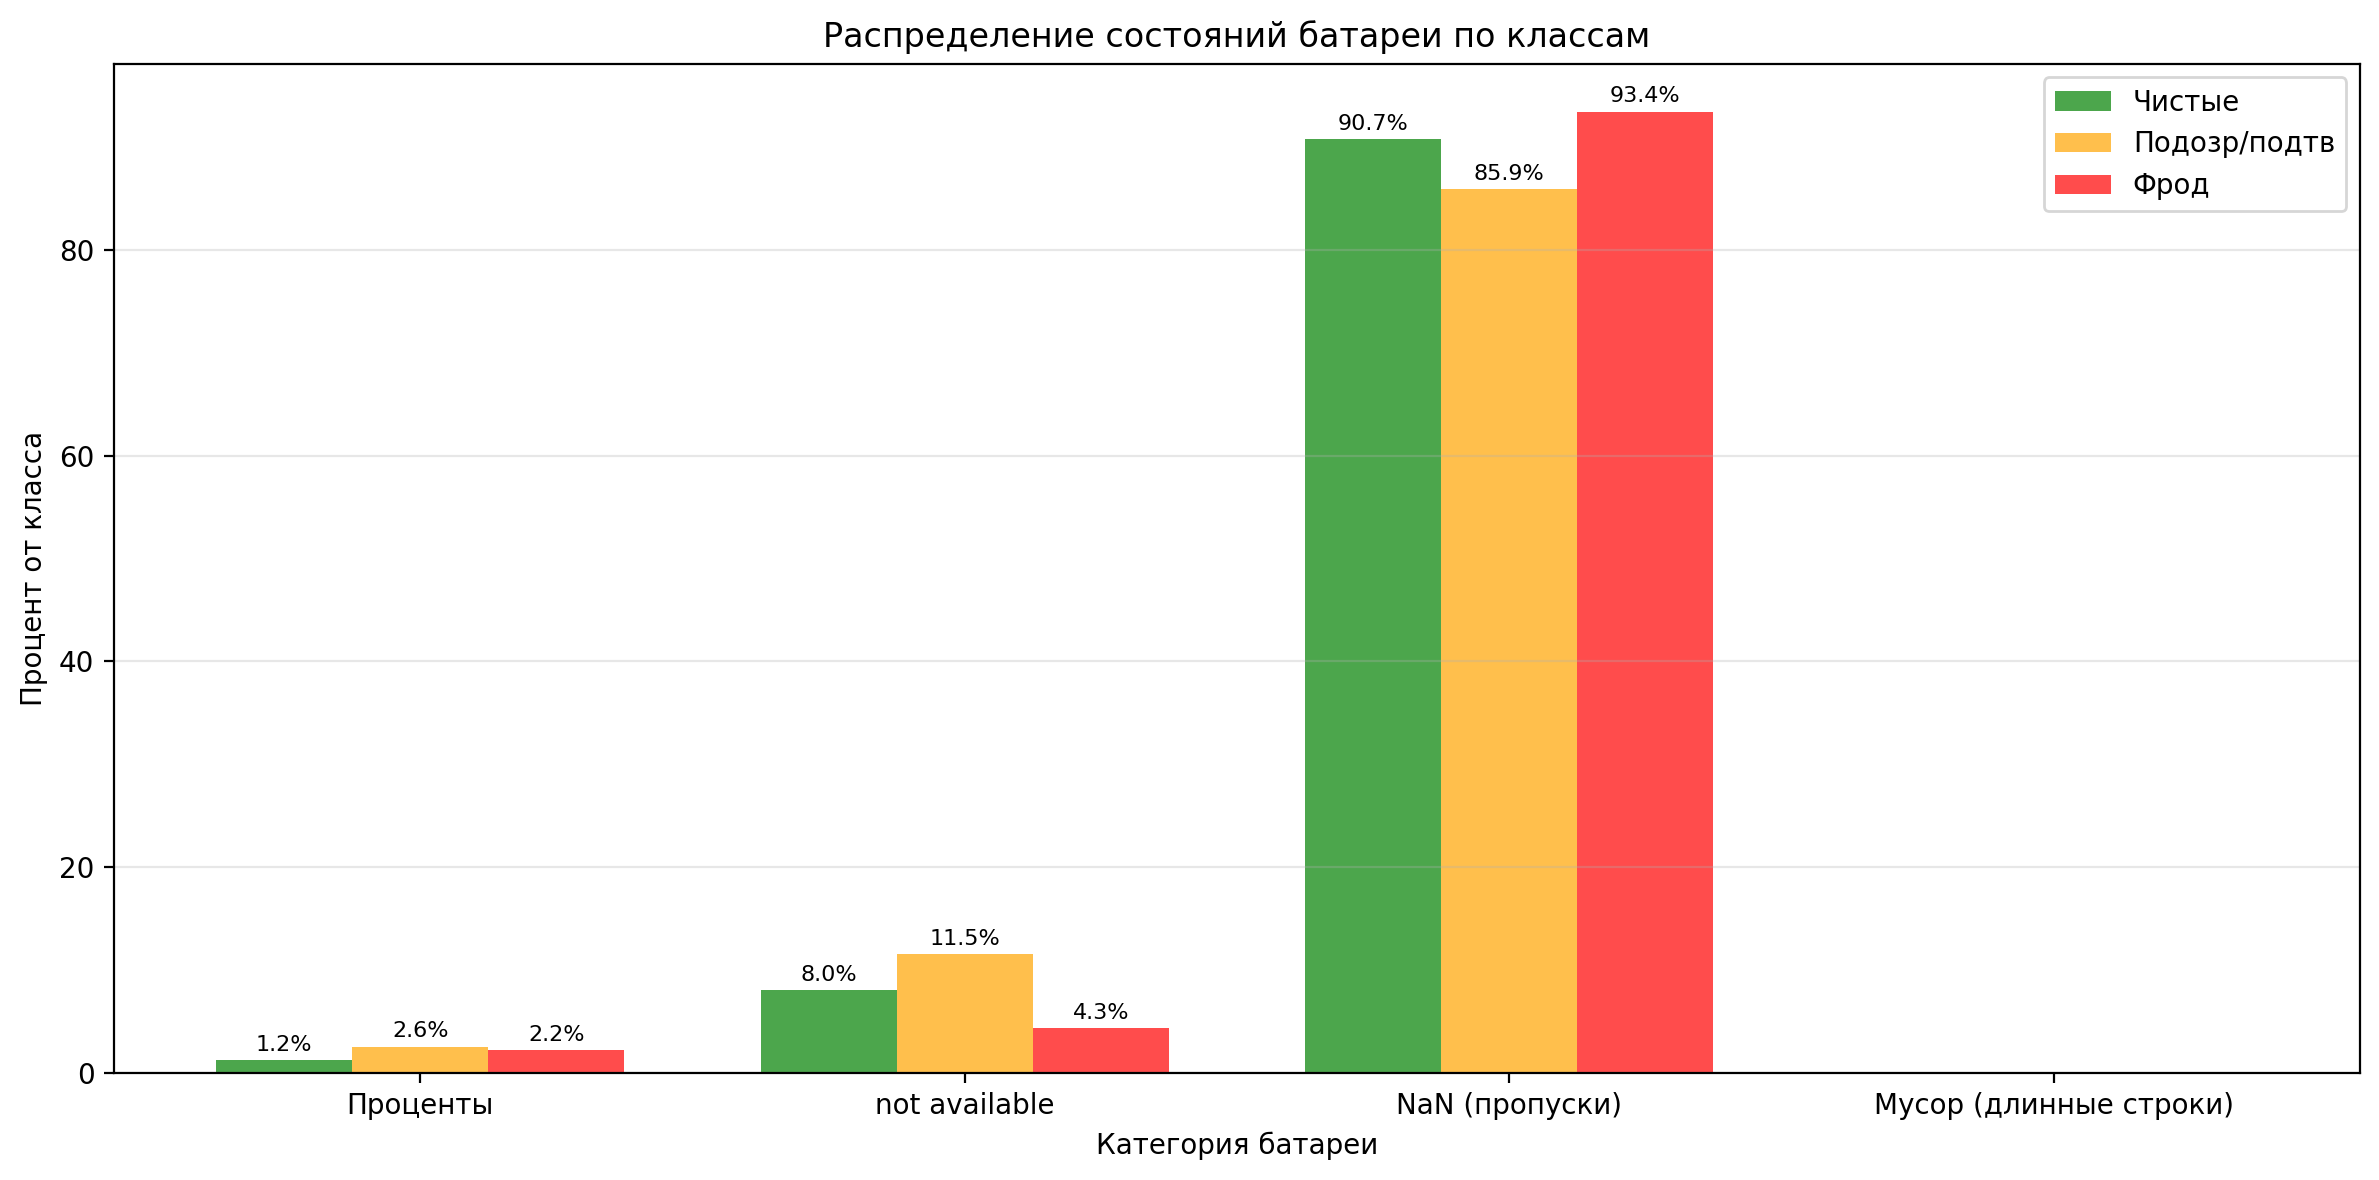

In [35]:
df_plot = train1_df.copy()

def get_battery_category(val):
    if pd.isna(val) or val == 'NaN%':
        return 'NaN (пропуски)'
    elif val == 'not available':
        return 'not available'
    elif isinstance(val, str) and val.endswith('%'):
        return 'Проценты'
    else:
        return 'Мусор (длинные строки)'

df_plot['battery_cat'] = df_plot['battery'].apply(get_battery_category)

total_dist = df_plot['battery_cat'].value_counts()
total_pct = df_plot['battery_cat'].value_counts(normalize=True) * 100

for cat in ['Проценты', 'not available', 'NaN (пропуски)', 'Мусор (длинные строки)']:
    if cat in total_dist.index:
        print(f"  {cat}: {total_dist[cat]} ({total_pct[cat]:.10f}%)")
    else:
        print(f"  {cat}: 0 (0.0000000000%)")

class_dist = {}

for target, name in [(-1, 'Чистые'), (0, 'Подозр/подтв'), (1, 'Фрод')]:
    subset = df_plot[df_plot['target'] == target]
    dist = subset['battery_cat'].value_counts(normalize=True) * 100
    class_dist[name] = dist
    print(f"\n{name} (n = {len(subset)}):")
    for cat in ['Проценты', 'not available', 'NaN (пропуски)', 'Мусор (длинные строки)']:
        if cat in dist.index:
            print(f"  {cat}: {dist[cat]:.2f}%")
        else:
            print(f"  {cat}: 0.0000000000%")

fig, ax = plt.subplots(figsize=(12, 6))

categories = ['Проценты', 'not available', 'NaN (пропуски)', 'Мусор (длинные строки)']
x = np.arange(len(categories))
width = 0.25

values = []
for name in ['Чистые', 'Подозр/подтв', 'Фрод']:
    values.append([class_dist[name].get(cat, 0) for cat in categories])

bars1 = ax.bar(x - width, values[0], width, label='Чистые', color='green', alpha=0.7)
bars2 = ax.bar(x, values[1], width, label='Подозр/подтв', color='orange', alpha=0.7)
bars3 = ax.bar(x + width, values[2], width, label='Фрод', color='red', alpha=0.7)

ax.set_xlabel('Категория батареи')
ax.set_ylabel('Процент от класса')
ax.set_title('Распределение состояний батареи по классам')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 1:
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                   f'{height:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

Создадим 3 бинарных признака: имеется/не имеется заряд; батарея недоступна; мусор. Четвертое значение (NaN) будет отсутствием значений во всех признаках.  
Примерно так:

In [37]:
"""
df['battery_percent'] = (df['battery'].astype(str).str.endswith('%') & (df['battery'] != 'NaN%')).astype(int)
df['battery_not_available'] = (df['battery'] == 'not available').astype(int)
df['battery_garbage'] = (~df['battery'].isna() & 
                         ~df['battery'].astype(str).str.endswith('%') & 
                         (df['battery'] != 'not available') & 
                         (df['battery'] != 'NaN%')).astype(int)
"""

"\ndf['battery_percent'] = (df['battery'].astype(str).str.endswith('%') & (df['battery'] != 'NaN%')).astype(int)\ndf['battery_not_available'] = (df['battery'] == 'not available').astype(int)\ndf['battery_garbage'] = (~df['battery'].isna() & \n                         ~df['battery'].astype(str).str.endswith('%') & \n                         (df['battery'] != 'not available') & \n                         (df['battery'] != 'NaN%')).astype(int)\n"